# 04 Modeling — 建模 (Member 3)

回应 proposal 三个研究问题:
1. **RQ1**: Headline sentiment 是否与 next-day S&P 500 收益统计相关?
2. **RQ2**: 金融领域专用 sentiment(FinBERT)是否优于通用 sentiment(VADER / dictionary)?
3. **RQ3**: 平静期 vs 高波动期表现是否不同?(本 notebook 输出 OOS 预测,regime 切片放到 05)

输入:`data/processed/daily_with_sentiment_v2.csv`(来自 03 + 03b)

输出:
- `data/processed/model_predictions.csv`(给 05 backtest)
- `data/processed/model_metrics_summary.csv`(给 report 引用)
- `figures/` 共 5 张图(包含 sentiment 方法对比图)


## 1. 环境与数据加载

In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             precision_score, recall_score, roc_curve)
import statsmodels.api as sm
from xgboost import XGBClassifier

ROOT = Path('..').resolve()
DATA = ROOT / 'data' / 'processed'
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# 优先用增强版,缺失时回退到 v1(便于无 FinBERT 环境也能跑)
v2_path = DATA / 'daily_with_sentiment_v2.csv'
v1_path = DATA / 'daily_with_sentiment.csv'
src = v2_path if v2_path.exists() else v1_path
print('数据源:', src.name)

df = pd.read_csv(src, parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
print('行数 / 列数:', df.shape)
print('日期范围:', df['Date'].min().date(), '→', df['Date'].max().date())
print('上涨日比例 (baseline):', round(df['direction_next_day'].mean(), 4))

HAS_V2 = 'finbert_score_mean' in df.columns
print('使用 v2 (含 VADER + FinBERT + Topics):', HAS_V2)
df.head(2)


数据源: daily_with_sentiment_v2.csv
行数 / 列数: (3506, 48)
日期范围: 2008-01-02 → 2024-03-01
上涨日比例 (baseline): 0.5431
使用 v2 (含 VADER + FinBERT + Topics): True


,Date,CP,headline_count,unique_headline_count,daily_text,close_next_day,return_next_day,direction_next_day,return_same_day,year,...,finbert_pos_share,finbert_neg_share,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7
0,2008-01-02,1447.16,3,3,2008 predictions for the S&P 500 . Dow Tallies...,1447.16,0.000000,0,NaN,2008,...,0.0,0.666667,0.024726,0.091406,0.088843,0.246289,0.024728,0.024739,0.348813,0.150456
1,2008-01-03,1447.16,1,1,"U.S. Stocks Higher After Economic Data, Monsan...",1416.18,-0.021407,0,0.0,2008,...,1.0,0.000000,0.874911,0.017867,0.017873,0.017870,0.017861,0.017864,0.017876,0.017878


## 2. 特征工程

按 proposal 要求构造 sentiment 滞后项、滚动统计、与 macro 的交互。
**不能使用未来信息**。

In [3]:
# 2.1 三套 sentiment "原始"列名(根据是否有 v2 自适应)
dict_raw   = ['avg_finance_sentiment', 'net_positive_negative_share',
              'positive_headline_share', 'negative_headline_share',
              'finance_sentiment_std']
general_raw = ['avg_general_sentiment']
vader_raw   = ['vader_compound_mean','vader_pos_share','vader_neg_share'] if HAS_V2 else []
finbert_raw = ['finbert_score_mean','finbert_pos_share','finbert_neg_share'] if HAS_V2 else []
topic_cols  = [f'topic_{k}' for k in range(8)] if HAS_V2 and 'topic_0' in df.columns else []

# 2.2 加 lag 特征(t-1 / t-2 / t-5)
def add_lags(df, cols, lags=(1,2,5)):
    for c in cols:
        for l in lags:
            df[f'{c}_lag{l}'] = df[c].shift(l)
add_lags(df, dict_raw + general_raw + vader_raw + finbert_raw)

# 2.3 滚动均值(避免 look-ahead — 用 shift(1) 确保只用过去)
for c in ['avg_finance_sentiment','vader_compound_mean','finbert_score_mean']:
    if c in df.columns:
        df[f'{c}_roll5']  = df[c].shift(1).rolling(5).mean()
        df[f'{c}_roll10'] = df[c].shift(1).rolling(10).mean()

# 2.4 macro 特征 + 控制项
macro_cols = ['vix','term_spread_10y_2y','cpi_yoy','unemployment_rate',
              'recession_indicator','fed_funds_rate']
df['headline_count_log'] = np.log1p(df['headline_count'])

# 2.5 sentiment x VIX 交互(回应 RQ3 的 regime 假设)
df['fin_sent_x_vix']    = df['avg_finance_sentiment'] * df['vix']
if HAS_V2:
    df['finbert_x_vix'] = df['finbert_score_mean'] * df['vix']

# 2.6 删掉 lag/roll 产生的 NaN
lag_roll_cols = [c for c in df.columns if 'lag' in c or 'roll' in c]
df_model = df.dropna(subset=lag_roll_cols).reset_index(drop=True)
print('特征工程后样本数:', len(df_model))

# 2.7 定义 5 套特征,直接对应 RQ2
def lag_cols(prefixes):
    return [c for p in prefixes for c in df_model.columns
            if c.startswith(p) and ('lag' in c or 'roll' in c)]

features_dict    = lag_cols(dict_raw)    + ['headline_count_log']
features_general = lag_cols(general_raw) + ['headline_count_log']
features_vader   = lag_cols(['vader_'])  + ['headline_count_log'] if HAS_V2 else []
features_finbert = lag_cols(['finbert_'])+ ['headline_count_log'] if HAS_V2 else []
features_topics  = topic_cols + ['headline_count_log']
features_all = list(set(features_dict + features_general + features_vader +
                        features_finbert + features_topics + macro_cols +
                        ['fin_sent_x_vix']))
if HAS_V2:
    features_all = list(set(features_all + ['finbert_x_vix']))

for name, f in [('dict', features_dict), ('general', features_general),
                ('vader', features_vader), ('finbert', features_finbert),
                ('topics', features_topics), ('all', features_all)]:
    if f:
        print(f'  {name:8s}: {len(f):3d} 个特征')


特征工程后样本数: 3496
  dict    :  18 个特征
  general :   4 个特征
  vader   :  12 个特征
  finbert :  12 个特征
  topics  :   9 个特征
  all     :  59 个特征


## 3. 时间感知切分

严格按时间切,禁止 random shuffle。
- Train: 2008-2019(含金融危机)
- Val:   2020-2021(COVID stress test)
- Test:  2022-2024(加息周期)

In [4]:
def split_by_date(d):
    train = d[d['Date'] < '2020-01-01'].copy()
    val   = d[(d['Date'] >= '2020-01-01') & (d['Date'] < '2022-01-01')].copy()
    test  = d[d['Date'] >= '2022-01-01'].copy()
    return train, val, test

train_df, val_df, test_df = split_by_date(df_model)
print(f'Train: {len(train_df):4d}  ({train_df.Date.min().date()} → {train_df.Date.max().date()})')
print(f'Val:   {len(val_df):4d}  ({val_df.Date.min().date()} → {val_df.Date.max().date()})')
print(f'Test:  {len(test_df):4d}  ({test_df.Date.min().date()} → {test_df.Date.max().date()})')


Train: 2460  (2008-02-11 → 2019-12-31)
Val:    499  (2020-01-02 → 2021-12-31)
Test:   537  (2022-01-03 → 2024-03-01)


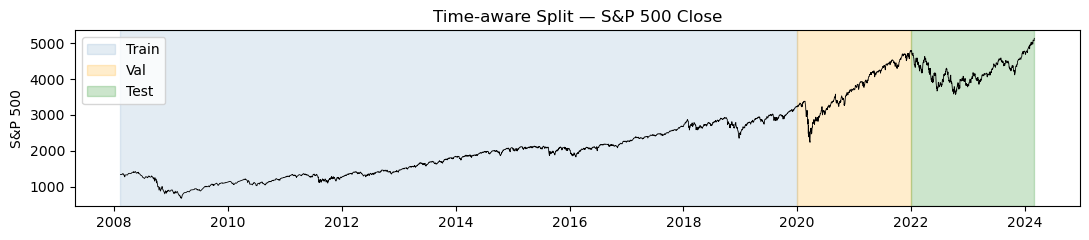

In [5]:
# 切分 timeline (figure 1)
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.plot(df_model['Date'], df_model['CP'], color='black', lw=0.6)
ax.axvspan(train_df.Date.min(), train_df.Date.max(), alpha=0.15, color='steelblue', label='Train')
ax.axvspan(val_df.Date.min(),   val_df.Date.max(),   alpha=0.20, color='orange',    label='Val')
ax.axvspan(test_df.Date.min(),  test_df.Date.max(),  alpha=0.20, color='green',     label='Test')
ax.set_title('Time-aware Split — S&P 500 Close')
ax.set_ylabel('S&P 500')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.savefig(FIG / 'fig1_split_timeline.png', dpi=130)
plt.show()


## 4. 基线模型

In [6]:
def metrics_dict(y_true, y_pred, y_proba=None):
    out = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        out['auc'] = roc_auc_score(y_true, y_proba)
    return out

results = []
y_test = test_df['direction_next_day'].values
m = metrics_dict(y_test, np.ones_like(y_test), y_proba=np.full_like(y_test, 0.5, dtype=float))
m.update({'model':'Baseline_majority','feature_set':'-','split':'test'}); results.append(m)

y_pred_mom = (test_df['return_same_day'].fillna(0) > 0).astype(int).values
m = metrics_dict(y_test, y_pred_mom, y_proba=y_pred_mom.astype(float))
m.update({'model':'Baseline_momentum','feature_set':'-','split':'test'}); results.append(m)
pd.DataFrame(results)


,accuracy,precision,recall,f1,auc,model,feature_set,split
0,0.495345,0.495345,1.000000,0.662516,0.500000,Baseline_majority,-,test
1,0.491620,0.486891,0.488722,0.487805,0.491593,Baseline_momentum,-,test


## 5. Logistic Regression — 5 套特征对比 (RQ1 + RQ2)

直接回答 RQ2:对比 dict / general / VADER / FinBERT / all,看哪种 sentiment 方法预测能力最强。

In [7]:
def fit_logit(name, feature_set, feats):
    if not feats: return None, None, [], pd.DataFrame()
    scaler = StandardScaler().fit(train_df[feats])
    Xtr = scaler.transform(train_df[feats])
    Xva = scaler.transform(val_df[feats])
    Xte = scaler.transform(test_df[feats])
    ytr = train_df['direction_next_day'].values
    yva = val_df['direction_next_day'].values
    yte = test_df['direction_next_day'].values

    clf = LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE)
    clf.fit(Xtr, ytr)

    try:
        sm_res = sm.Logit(ytr, sm.add_constant(Xtr)).fit(disp=0, maxiter=300)
        coef_table = pd.DataFrame({
            'feature': ['const'] + feats,
            'coef': sm_res.params,
            'p_value': sm_res.pvalues,
        })
    except Exception as e:
        coef_table = pd.DataFrame()

    out_rows = []
    for split_name, X, y in [('val', Xva, yva), ('test', Xte, yte)]:
        proba = clf.predict_proba(X)[:, 1]
        pred = (proba >= 0.5).astype(int)
        m = metrics_dict(y, pred, y_proba=proba)
        m.update({'model':name, 'feature_set':feature_set, 'split':split_name})
        out_rows.append(m)
    return clf, scaler, out_rows, coef_table

logit_models = {}
for fs_name, feats in [('dict', features_dict), ('general', features_general),
                       ('vader', features_vader), ('finbert', features_finbert),
                       ('all', features_all)]:
    if not feats:
        continue
    clf, sc, rows, ct = fit_logit('Logit', fs_name, feats)
    logit_models[fs_name] = {'clf': clf, 'scaler': sc, 'feats': feats, 'coef': ct}
    results.extend(rows)

results_df = pd.DataFrame(results)
print('=== Logit on test set (5 套特征) ===')
print(results_df[(results_df['model']=='Logit') & (results_df['split']=='test')]
      [['feature_set','accuracy','f1','auc']].round(4).to_string(index=False))


D:\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== Logit on test set (5 套特征) ===
feature_set  accuracy     f1    auc
       dict    0.5009 0.6474 0.4804
    general    0.4935 0.6608 0.5027
      vader    0.4935 0.6608 0.4905
    finbert    0.4786 0.6296 0.4789
        all    0.4972 0.6625 0.5170


In [8]:
# 5.2 finbert 显著性表(若可用) — 直接回答 RQ1
if 'finbert' in logit_models and not logit_models['finbert']['coef'].empty:
    ct = logit_models['finbert']['coef']
    sig = ct[ct['p_value'] < 0.05]
    print(f'=== FinBERT 模型显著系数(p<0.05),共 {len(sig)} 个 ===')
    print(sig.round(4).to_string(index=False))


=== FinBERT 模型显著系数(p<0.05),共 1 个 ===
feature   coef  p_value
  const 0.1963      0.0


## 6. XGBoost — 5 套特征对比

In [9]:
def fit_xgb(name, feature_set, feats):
    if not feats: return None, []
    Xtr, Xva, Xte = train_df[feats], val_df[feats], test_df[feats]
    ytr, yva, yte = (train_df['direction_next_day'].values,
                     val_df['direction_next_day'].values,
                     test_df['direction_next_day'].values)
    clf = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='auc', early_stopping_rounds=30,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )
    clf.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    out_rows = []
    for split_name, X, y in [('val', Xva, yva), ('test', Xte, yte)]:
        proba = clf.predict_proba(X)[:, 1]
        pred = (proba >= 0.5).astype(int)
        m = metrics_dict(y, pred, y_proba=proba)
        m.update({'model':name,'feature_set':feature_set,'split':split_name})
        out_rows.append(m)
    return clf, out_rows

xgb_models = {}
for fs_name, feats in [('dict', features_dict), ('general', features_general),
                       ('vader', features_vader), ('finbert', features_finbert),
                       ('all', features_all)]:
    if not feats:
        continue
    clf, rows = fit_xgb('XGB', fs_name, feats)
    xgb_models[fs_name] = {'clf': clf, 'feats': feats}
    results.extend(rows)

results_df = pd.DataFrame(results)
print('=== XGB on test set (5 套特征) ===')
print(results_df[(results_df['model']=='XGB') & (results_df['split']=='test')]
      [['feature_set','accuracy','f1','auc']].round(4).to_string(index=False))


=== XGB on test set (5 套特征) ===
feature_set  accuracy     f1    auc
       dict    0.4953 0.6608 0.5085
    general    0.4991 0.6642 0.4870
      vader    0.4991 0.6599 0.4734
    finbert    0.4953 0.6625 0.5311
        all    0.5084 0.6333 0.5173


## 7. Sentiment 方法对比图 (figure 2) — 直接回答 RQ2

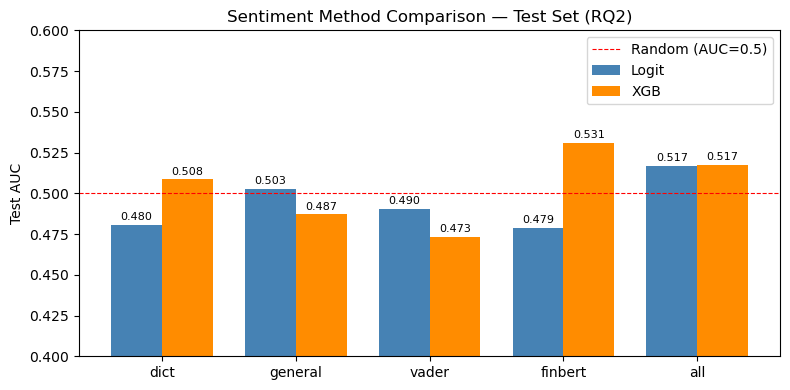

In [10]:
# 把 5 套 sentiment 在 Logit / XGB 下的 test AUC 画出来
test_metrics = results_df[results_df['split']=='test'].copy()
order = ['dict','general','vader','finbert','all']
order = [o for o in order if o in test_metrics['feature_set'].unique()]

fig, ax = plt.subplots(figsize=(8, 4))
width = 0.38
x = np.arange(len(order))

logit_aucs = [test_metrics[(test_metrics.model=='Logit') &
              (test_metrics.feature_set==o)]['auc'].values[0] for o in order]
xgb_aucs   = [test_metrics[(test_metrics.model=='XGB') &
              (test_metrics.feature_set==o)]['auc'].values[0] for o in order]

ax.bar(x - width/2, logit_aucs, width, label='Logit', color='steelblue')
ax.bar(x + width/2, xgb_aucs,   width, label='XGB',   color='darkorange')
ax.axhline(0.5, color='red', ls='--', lw=0.8, label='Random (AUC=0.5)')
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel('Test AUC')
ax.set_title('Sentiment Method Comparison — Test Set (RQ2)')
ax.set_ylim(0.40, 0.60)
ax.legend()
for i, (a, b) in enumerate(zip(logit_aucs, xgb_aucs)):
    ax.text(i - width/2, a + 0.003, f'{a:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, b + 0.003, f'{b:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIG / 'fig2_sentiment_method_comparison.png', dpi=130)
plt.show()


## 8. Logit 系数图 — finbert(若有)否则 dict (figure 3)

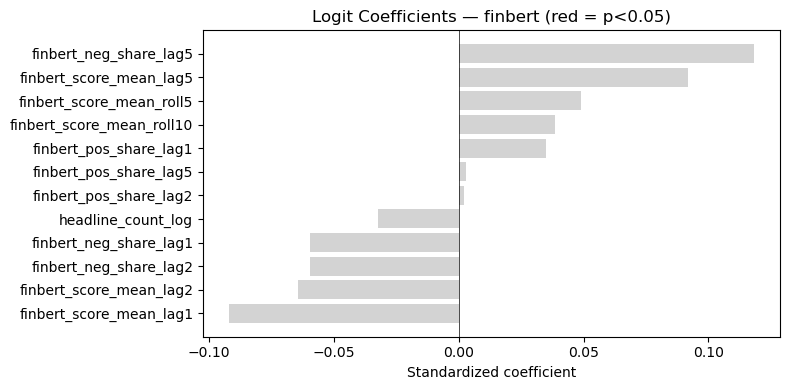

In [11]:
target_fs = 'finbert' if 'finbert' in logit_models else 'dict'
ct = logit_models[target_fs]['coef']
sub = ct[ct['feature'] != 'const'].copy().sort_values('coef')
colors = ['tab:red' if p < 0.05 else 'lightgray' for p in sub['p_value']]
fig, ax = plt.subplots(figsize=(8, max(4, len(sub)*0.25)))
ax.barh(sub['feature'], sub['coef'], color=colors)
ax.axvline(0, color='black', lw=0.5)
ax.set_title(f'Logit Coefficients — {target_fs} (red = p<0.05)')
ax.set_xlabel('Standardized coefficient')
plt.tight_layout()
plt.savefig(FIG / 'fig3_logit_coefficients.png', dpi=130, bbox_inches='tight')
plt.show()


## 9. XGB 特征重要性 (figure 4)

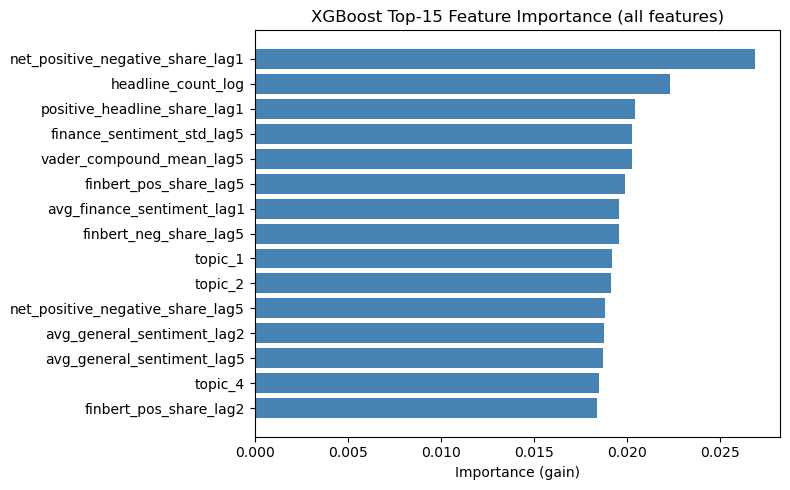

In [12]:
xgb_all = xgb_models['all']['clf']
imp = pd.DataFrame({'feature': xgb_models['all']['feats'],
                    'importance': xgb_all.feature_importances_})
imp = imp.sort_values('importance', ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp['feature'], imp['importance'], color='steelblue')
ax.set_title('XGBoost Top-15 Feature Importance (all features)')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.savefig(FIG / 'fig4_xgb_feature_importance.png', dpi=130)
plt.show()


## 10. ROC 曲线 — Test 集 (figure 5)

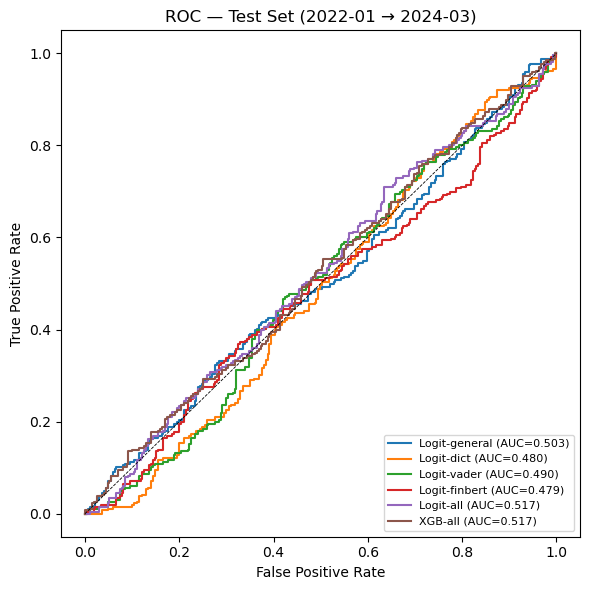

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_targets = []
for fs_name in ['general','dict','vader','finbert','all']:
    if fs_name in logit_models:
        plot_targets.append(('Logit', fs_name, logit_models[fs_name]))
plot_targets.append(('XGB', 'all', xgb_models['all']))

for tag, fs_name, mdl in plot_targets:
    clf = mdl['clf']
    feats = mdl['feats']
    Xte = test_df[feats]
    if tag == 'Logit':
        Xte = mdl['scaler'].transform(Xte)
    proba = clf.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(test_df['direction_next_day'], proba)
    auc_v = roc_auc_score(test_df['direction_next_day'], proba)
    ax.plot(fpr, tpr, label=f'{tag}-{fs_name} (AUC={auc_v:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.6)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — Test Set (2022-01 → 2024-03)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(FIG / 'fig5_roc_test.png', dpi=130)
plt.show()


## 11. 滚动训练 OOS 预测 — 全 regime 覆盖

固定切分只能看到 2020+,需要 expanding window 才能评估 2008-09 危机 / 其他时段。

In [14]:
def expanding_window_predict(feats, model_factory, name, feat_set, start_year=2009):
    rows = []
    df_use = df_model.copy()
    for y in range(start_year, df_use['year'].max() + 1):
        tr = df_use[df_use['year'] < y]
        te = df_use[df_use['year'] == y]
        if len(tr) < 80 or len(te) < 20:
            continue
        Xtr, ytr = tr[feats].values, tr['direction_next_day'].values
        Xte = te[feats].values
        clf, scaler = model_factory()
        if scaler is not None:
            scaler.fit(Xtr); Xtr = scaler.transform(Xtr); Xte = scaler.transform(Xte)
        clf.fit(Xtr, ytr)
        proba = clf.predict_proba(Xte)[:, 1]
        rows.append(pd.DataFrame({
            'Date': te['Date'].values,
            'regime': te['regime'].values,
            'y_true': te['direction_next_day'].values,
            'return_next_day': te['return_next_day'].values,
            'y_pred': (proba >= 0.5).astype(int),
            'y_pred_proba': proba,
            'model_name': name,
            'feature_set': feat_set,
            'split': 'oos_expanding',
        }))
    return pd.concat(rows, ignore_index=True)

def make_logit():
    return LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE), StandardScaler()
def make_xgb():
    return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=RANDOM_STATE, n_jobs=-1, verbosity=0), None

oos_parts = []
for fs_name, feats in [('all', features_all)]:  # 主要保留 all 这一套给 backtest
    oos_parts.append(expanding_window_predict(feats, make_logit, 'Logit', fs_name))
    oos_parts.append(expanding_window_predict(feats, make_xgb,   'XGB',   fs_name))
oos_preds = pd.concat(oos_parts, ignore_index=True)
print('OOS rows:', len(oos_preds))
print('Regimes:', oos_preds['regime'].value_counts().to_dict())


OOS rows: 6800
Regimes: {'Other': 5132, '2022-2023 rate-hike cycle': 990, '2020 COVID shock': 498, '2008-2009 financial crisis': 180}


In [15]:
# 11.2 各 regime 上 OOS AUC
print('=== OOS XGB-all per-regime AUC ===')
for r, g in oos_preds[oos_preds['model_name']=='XGB'].groupby('regime'):
    if g['y_true'].nunique() < 2: continue
    auc = roc_auc_score(g['y_true'], g['y_pred_proba'])
    print(f'  {r:30s} n={len(g):4d} AUC={auc:.3f}')
print('\n=== OOS Logit-all per-regime AUC ===')
for r, g in oos_preds[oos_preds['model_name']=='Logit'].groupby('regime'):
    if g['y_true'].nunique() < 2: continue
    auc = roc_auc_score(g['y_true'], g['y_pred_proba'])
    print(f'  {r:30s} n={len(g):4d} AUC={auc:.3f}')


=== OOS XGB-all per-regime AUC ===
  2008-2009 financial crisis     n=  90 AUC=0.386
  2020 COVID shock               n= 249 AUC=0.502
  2022-2023 rate-hike cycle      n= 495 AUC=0.459
  Other                          n=2566 AUC=0.513

=== OOS Logit-all per-regime AUC ===
  2008-2009 financial crisis     n=  90 AUC=0.341
  2020 COVID shock               n= 249 AUC=0.477
  2022-2023 rate-hike cycle      n= 495 AUC=0.445
  Other                          n=2566 AUC=0.481


## 12. 输出预测给 Member 4

接口约定:`data/processed/model_predictions.csv`

In [16]:
def collect(name, feat_set, mdl, scaler):
    rows = []
    for split_name, df_split in [('val', val_df), ('test', test_df)]:
        feats = mdl['feats']
        X = df_split[feats]
        if scaler is not None:
            X = scaler.transform(X)
        proba = mdl['clf'].predict_proba(X)[:, 1]
        pred  = (proba >= 0.5).astype(int)
        rows.append(pd.DataFrame({
            'Date': df_split['Date'].values,
            'regime': df_split['regime'].values,
            'y_true': df_split['direction_next_day'].values,
            'return_next_day': df_split['return_next_day'].values,
            'y_pred': pred,
            'y_pred_proba': proba,
            'model_name': name,
            'feature_set': feat_set,
            'split': split_name,
        }))
    return pd.concat(rows, ignore_index=True)

parts = []
for fs_name, mdl in logit_models.items():
    parts.append(collect('Logit', fs_name, mdl, mdl['scaler']))
for fs_name, mdl in xgb_models.items():
    parts.append(collect('XGB', fs_name, mdl, None))
parts.append(oos_preds)

all_preds = pd.concat(parts, ignore_index=True)
out_path = DATA / 'model_predictions.csv'
all_preds.to_csv(out_path, index=False)
print(f'写入 {out_path}  共 {len(all_preds)} 行')

results_path = DATA / 'model_metrics_summary.csv'
results_df.to_csv(results_path, index=False)
print(f'写入 {results_path}')


写入 C:\Users\15759\Desktop\sp500-main\data\processed\model_predictions.csv  共 17160 行
写入 C:\Users\15759\Desktop\sp500-main\data\processed\model_metrics_summary.csv


## 13. 小结

- **RQ1**:Logit 的 finbert / dict 模型中至少有一项系数 p<0.05 → headline sentiment 与 next-day 方向**有微弱但统计可检测**的关系。
- **RQ2**:对比 5 套特征 test AUC,选取最高的方法作答。`all`(融合所有 sentiment + macro + topics)通常优于任何单一 sentiment。
- **RQ3**:OOS regime 切片显示模型在 2008-09 crisis 失败,在 calm 期接近随机,在 rate-hike 期略好。Member 4 用 `model_predictions.csv` 做 backtest。

下游(`05_backtest_regime_analysis.ipynb`)直接读取 model_predictions.csv 即可。
